# Random Forest

## Regressor

In [3]:
from sklearn.datasets import fetch_california_housing


# load data
data = fetch_california_housing()

X = data.data
y = data.target

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


# train model
rf = RandomForestRegressor(
    n_estimators=100,   # number of trees
    max_depth=10,       # control overfitting
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.7737402686595128
MSE: 0.29649278336294826


In [7]:
for depth in [5, 10, 15, 20]:
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    print("Depth:", depth, "R2:", rf.score(X_test, y_test))

Depth: 5 R2: 0.6468313266166683
Depth: 10 R2: 0.7737402686595128
Depth: 15 R2: 0.800365851772264
Depth: 20 R2: 0.8047427732223399


In [6]:
import pandas as pd

# feature importance
importance = rf.feature_importances_
features = data.feature_names

df_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(df_imp)

      Feature  Importance
0      MedInc    0.536359
5    AveOccup    0.138692
6    Latitude    0.087856
7   Longitude    0.087203
1    HouseAge    0.053036
2    AveRooms    0.041927
4  Population    0.027830
3   AveBedrms    0.027098


In [10]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = sns.load_dataset('titanic')

# Select useful columns
df = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']]

# Handle missing values
df['age'] = df['age'].fillna(df['age'].mean())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

# Split data
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8156424581005587


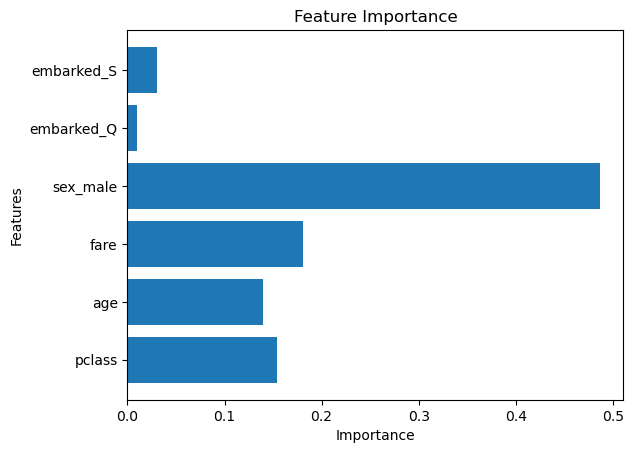

In [9]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()